<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The Kernel Trick - Intuition and Visualization</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Understand why some data can't be separated by a straight line.</li>
<li>Understand what the "kernel trick" is and why it's useful.</li>
<li>Visualize how data becomes separable after transforming it to a higher dimension.</li>
<li>See how different kernels (linear, polynomial, RBF) shape the decision boundary.</li>
</ol>
In the previous notebooks, all our data could be separated by a straight line 
(a linear hyperplane). 

But real-world data is often messier than that. 
This notebook explores what happens when a straight line just isn't enough.
</div>

In [1]:
# Importing libraries 

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

from sklearn.datasets import make_circles
from sklearn.svm import SVC

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The Problem: Non-Linearly Separable Data</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's create a dataset where one class forms a circle around the other class. 

No matter how we draw a straight line on this 2D plane, we simply 
<b>cannot separate the two classes</b> properly.
<br><br>
This is where a simple linear SVM fails - and where the kernel trick comes in.
</div>

In [ ]:
# Creating a dataset where one class surrounds the other 
X, y = make_circles(n_samples=200, factor=0.4, noise=0.05, random_state=42)

print("Shape of data:", X.shape)
print("Classes:", np.unique(y))

Shape of data: (200, 2)
Classes: [0 1]


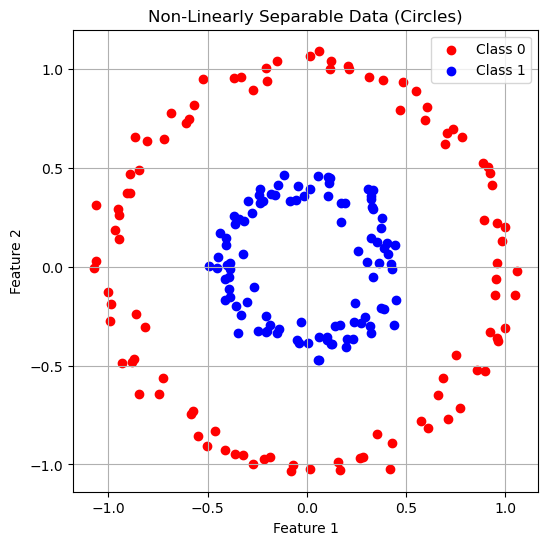

In [3]:
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

plt.title("Non-Linearly Separable Data (Circles)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What Happens with a Linear SVM?</b>
</h2>
<div style="font-family:'Times New Roman';">
Just to confirm the problem - let's try fitting a <b>linear SVM</b> 
on this data and see how badly it performs.

 The decision boundary 
will be a straight line, which clearly can't separate a circle 
from its surrounding ring.
</div>

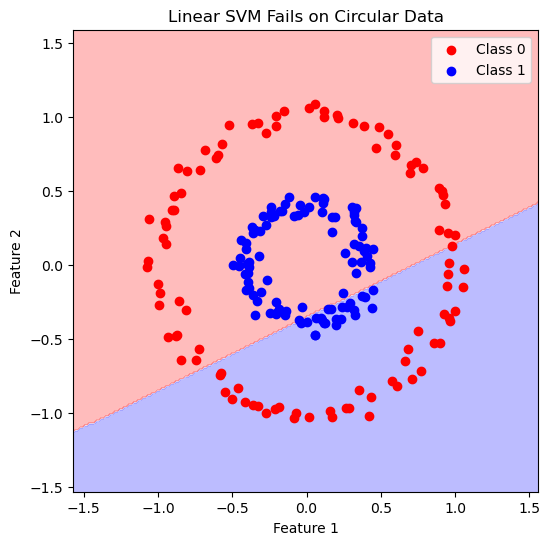

Accuracy: 58.50%


In [4]:
# Training a linear SVM 
linear_model = SVC(kernel='linear')
linear_model.fit(X, y)

# Creating a mesh grid for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))

Z = linear_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

plt.title("Linear SVM Fails on Circular Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.axis('equal')
plt.show()

print(f"Accuracy: {linear_model.score(X, y) * 100:.2f}%")

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The Idea: What if We Add a New Dimension?</b>
</h2>
<div style="font-family:'Times New Roman';">
Here's the key idea: even though the data isn't separable in 2D, 
it might become separable if we <b>project it into a higher dimension</b>.
<br><br>
For this circular data, notice that the inner circle (Class 0) and 
outer ring (Class 1) differ mainly by their <b>distance from the center</b>. 
So, let's add a third dimension:
<br><br>
<b>z = x² + y²</b>
<br><br>
This is essentially measuring how far each point is from the origin. 
Points in the inner circle will have a small "z" value, and points 
in the outer ring will have a larger "z" value - creating separation 
along this new axis.
<br><br>
This is the core idea of the <b>kernel trick</b>: transform the data 
into a higher-dimensional space where it <i>becomes</i> linearly separable, 
find a hyperplane there, and it corresponds to a 
<b>non-linear boundary</b> back in the original space.
</div>

In [5]:
# Creating a new feature: z = x^2 + y^2 (distance from origin, squared)
z = X[:, 0]**2 + X[:, 1]**2

print("First 5 values of z:", z[:5])
print("\nNotice how 'z' differs between the two classes:")
print("Mean z for Class 0:", z[y == 0].mean())
print("Mean z for Class 1:", z[y == 1].mean())

First 5 values of z: [0.9596368  1.01966594 0.87171437 0.17527598 0.22678601]

Notice how 'z' differs between the two classes:
Mean z for Class 0: 1.00580878319998
Mean z for Class 1: 0.16771960302905484


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing the Data in 3D</b>
</h2>
<div style="font-family:'Times New Roman';">
Now let's plot the data using all three dimensions: 
<b>x, y, and z = x² + y²</b>.
<br><br>
Watch what happens - the two classes that were tangled together in 2D 
should now separate into two distinct "layers" along the z-axis, 
making it possible to slice them apart with a flat plane (a hyperplane in 3D).
</div>

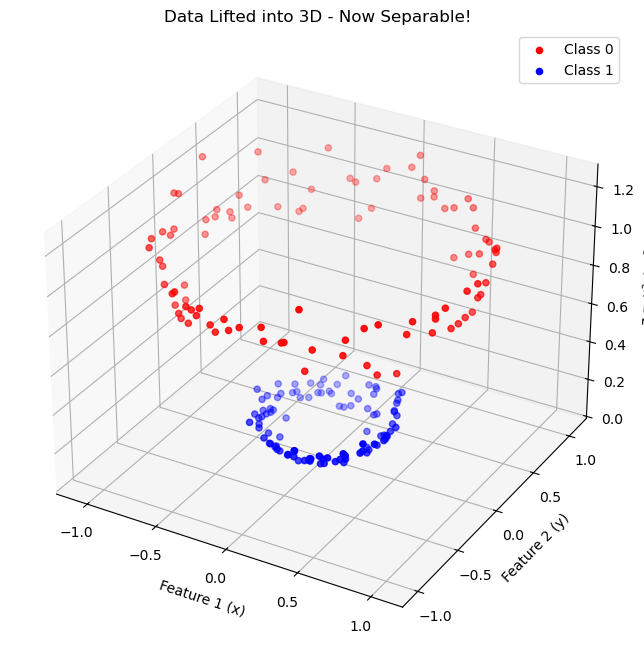

In [6]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting both classes in 3D
ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], z[y == 0],
           color='red', label='Class 0')
ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], z[y == 1],
           color='blue', label='Class 1')

ax.set_xlabel("Feature 1 (x)")
ax.set_ylabel("Feature 2 (y)")
ax.set_zlabel("z = x² + y²")
ax.set_title("Data Lifted into 3D - Now Separable!")
ax.legend()

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Separating the Data with a Hyperplane in 3D</b>
</h2>
<div style="font-family:'Times New Roman';">
In 3D, the two classes are now separated by their "height" (z-value). 
A flat horizontal plane - say, at <b>z = 0.5</b> - can now 
cleanly separate Class 0 (low z) from Class 1 (high z).
<br><br>
This flat plane in 3D corresponds to a <b>circular boundary</b> back 
in our original 2D space - exactly the kind of boundary we need
</div>

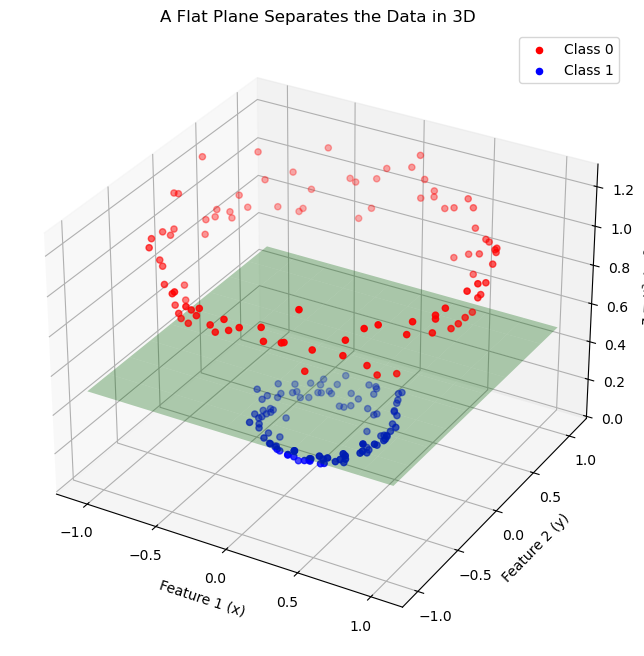

In [7]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], z[y == 0],
           color='red', label='Class 0')
ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], z[y == 1],
           color='blue', label='Class 1')

# Creating a flat plane at z = 0.5 to separate the two classes
xx_plane, yy_plane = np.meshgrid(
    np.linspace(X[:, 0].min(), X[:, 0].max(), 10),
    np.linspace(X[:, 1].min(), X[:, 1].max(), 10)
)
zz_plane = np.full_like(xx_plane, 0.5)  # flat plane at z = 0.5

ax.plot_surface(xx_plane, yy_plane, zz_plane, alpha=0.3, color='green')

ax.set_xlabel("Feature 1 (x)")
ax.set_ylabel("Feature 2 (y)")
ax.set_zlabel("z = x² + y²")
ax.set_title("A Flat Plane Separates the Data in 3D")
ax.legend()

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What This Plane Looks Like Back in 2D</b>
</h2>
<div style="font-family:'Times New Roman';">
The flat plane at <b>z = 0.5</b> equation 
<b>x² + y² = 0.5</b> - which is just the equation of a 
<b>circle</b>
<br><br>
So a simple flat plane in 3D becomes a circular decision boundary 
when projected back into our original 2D space. 


This is exactly what we needed to separate the inner circle from the outer ring.
</div>

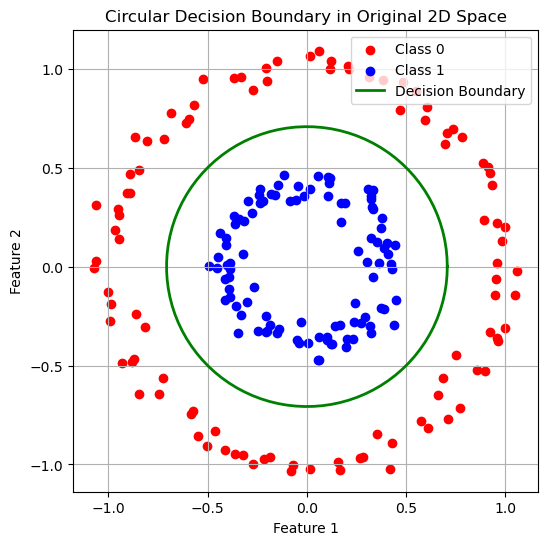

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

# Drawing the circular boundary: x^2 + y^2 = 0.5
theta = np.linspace(0, 2 * np.pi, 100)
radius = np.sqrt(0.5)
circle_x = radius * np.cos(theta)
circle_y = radius * np.sin(theta)

plt.plot(circle_x, circle_y, color='green', linewidth=2, label='Decision Boundary')

plt.title("Circular Decision Boundary in Original 2D Space")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why It's Called a "Trick"</b>
</h2>
<div style="font-family:'Times New Roman';">
Here is the clever part: to find the separating hyperplane, SVM only 
needs to compute <b>dot products</b> between data points  it never 
actually needs the transformed coordinates themselves.
<br><br>
A <b>kernel function</b> computes what the dot product 
<i>would be</i> in the higher-dimensional space  directly from the 
original points  <b>without ever actually transforming the data</b>.
<br><br>
This means we get all the benefits of working in a higher dimension 
(like our 3D example) <b>without the computational cost</b> of 
actually computing those extra dimensions. That's the "trick"!
<br><br>
Common kernel functions:
<ul>
<li><b>Linear:</b> K(x, y) = x · y</li>
<li><b>Polynomial:</b> K(x, y) = (x · y + c)^d</li>
<li><b>RBF (Radial Basis Function):</b> K(x, y) = exp(-γ ||x - y||²)</li>
</ul>
</div>

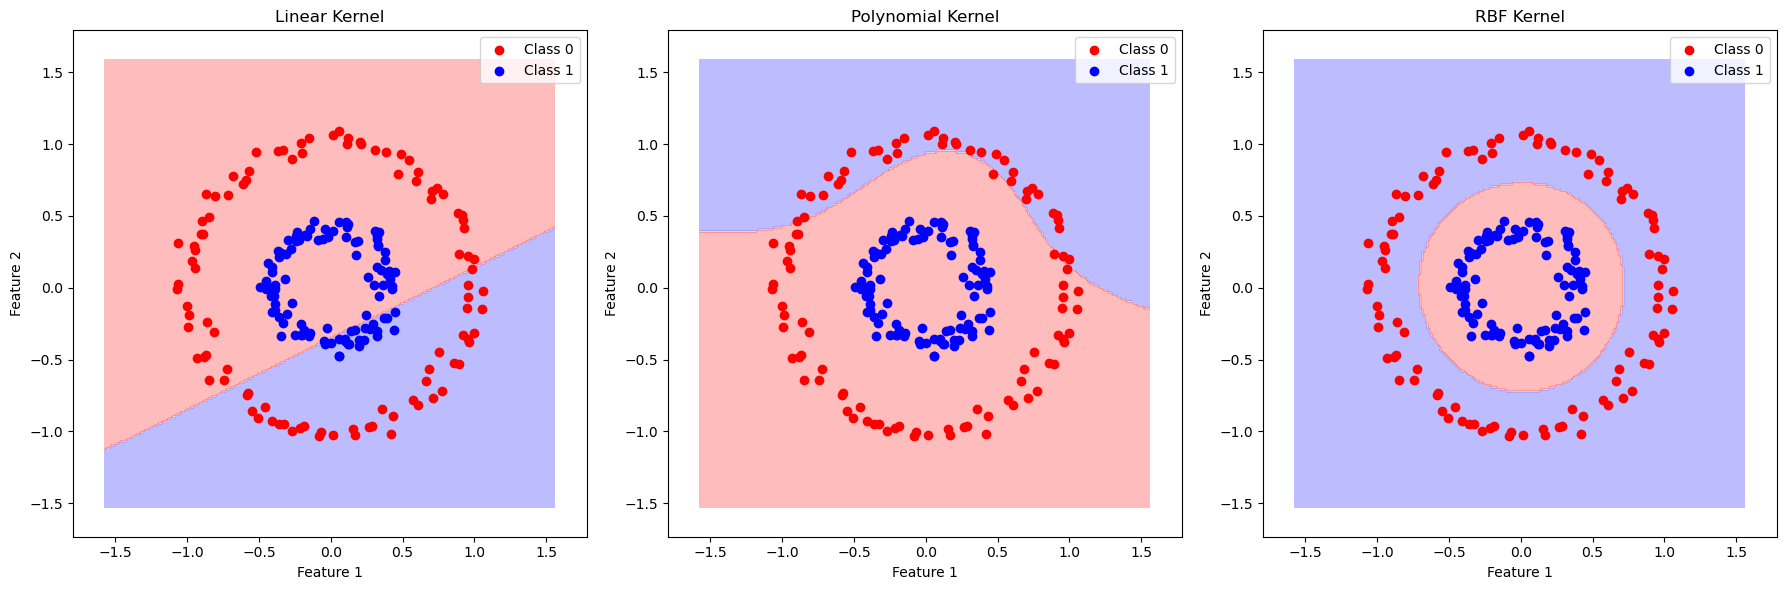

In [9]:
# Comparing Kernels
kernels = ['linear', 'poly', 'rbf']
titles = ['Linear Kernel', 'Polynomial Kernel', 'RBF Kernel']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, kernel, title in zip(axes, kernels, titles):
    # Training an SVM with the current kernel
    model = SVC(kernel=kernel, gamma='auto')
    model.fit(X, y)

    # Creating mesh grid for decision boundary
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotting decision boundary and data
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()
    ax.axis('equal')

plt.tight_layout()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Some data (like circles) <b>cannot be separated by a straight line</b> in its original space.</li>
<li>By <b>adding extra dimensions</b> (like z = x² + y²), the data can become 
linearly separable in higher-dimensional space.</li>
<li>A flat hyperplane in higher dimensions corresponds to a 
<b>curved decision boundary</b> back in the original space.</li>
<li>The <b>kernel trick</b> lets SVM compute this higher-dimensional 
separation efficiently - without explicitly transforming the data.</li>
<li>Different kernels (<b>linear, polynomial, RBF</b>) create different 
shapes of decision boundaries, suited to different types of data.</li>
</ul>
This notebook focused purely on <b>intuition and visualization</b>. 
Next, I can dive deeper into tuning kernel parameters like 
<b>C, gamma, and degree</b> and see how they affect the decision boundary.
</div>